In [1]:
# read data files 
import pandas as pd 
from utils.eval import * 
from utils.embedding import * 
df_TUE = pd.read_csv('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/TUE/all_CS_courses.csv')
df_OVL = pd.read_csv('/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/TUE/all_overlap_courses.csv')
filename = "/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/data/TUE/overlap_table.csv"
df_overlap = pd.read_csv(filename)

print(df_TUE.head())
# Load sBERT tokenizer 
import nltk 
nltk.download('punkt') 
nltk.download('punkt_tab')
from nltk.tokenize import sent_tokenize 
from sentence_transformers import SentenceTransformer 
import numpy as np 
import torch 

model_name = "sentence-transformers/all-mpnet-base-v2"   # sBERT model
model = SentenceTransformer(model_name)
tokenizer = model.tokenizer
max_tokens = 256  # model limit

[nltk_data] Downloading package punkt to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/transformers/utils/hub.py:128: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(


                                             title credits             level  \
0                   Measure and Probability Theory    5 EC          Advanced   
1                    Automata and Formal Languages    5 EC          Bachelor   
2                  Linear Algebra for Data Science    5 EC               BSc   
3          Impact of technology engineering ethics    5 EC               NaN   
4  Stochastic Optimization Models for Data Science    5 EC  Bachelor College   

                                         description  \
0  In this course, you will discover how measure ...   
1  This course covers fundamental concepts and th...   
2  Systems of linear equations are often used in ...   
3  Ethics of Technology and Engineering introduce...   
4  All information regarding this course (incl. l...   

                                              topics  \
0  ['Measures, measurable functions and sigma-alg...   
1  ['deterministic finite automaton (DFA)', 'non-...   
2  ['Systems o

[nltk_data] Downloading package punkt to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /cephyr/users/nijdam/Alvis/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [2]:
# find all positive pairs 
# manually input all old codes 
old_codes = ['2WN30', '2WF50', 'JBI040', '2WA30', 'JBM060', '2WF70', '2IT90', '2ILH0', 
             '2WA80', 'JBM020', 'JBM010', 'JBI025', 'JBI020', 'JBM090', 'JBM090-B-5', '2IAB0', '2WS30', '2WF60', 
             '2WF80', '2WN20', 'JBL120', '2WF20', '2WF20', '2WF30', '2DBI00', '2DRR00', 'JBM070', '2WO020', 
             '2WH60', '2WAG0', '2IC60', '2WN40', '2WA90', '2WS20', '2WH20', '2WB40', '2WS40', '2IC60', '2WF40', 
             '2IIG0', '2WB20', '2WB50', '2WA70', '2WA60'] 
#print(len(old_codes))
positives = []
for i in range(len(df_TUE['course_code'])): 
    result = df_overlap.loc[df_overlap['New_code'] == df_TUE['course_code'][i], 'Overlap'] 
    #print(result.iloc[0])
    los = df_TUE.loc[df_TUE['course_code'] == df_TUE['course_code'][i],'learning_outcomes']
    #print(los)
    if los.iloc[0] != '[]': # both los need to be available 
        #print('yes')
        codes = str(result.iloc[0]).split()
        true_overlap = [(ii,code) for ii,code in enumerate(codes) if code not in old_codes and code != 'nan']
        for overlap_course in true_overlap: 
            if len(overlap_course[1]) >= 4: # filter out '+'
                los = df_OVL.loc[df_OVL['course_code'] == overlap_course[1],'learning_outcomes']
                if not los.empty:
                    if los.iloc[0] != '[]': 
                        #print('yes')
                        positives.append((df_TUE['course_code'][i], overlap_course[1])) 
        
print(len(positives))
#print(positives[0])

60


In [3]:
# sanity check
print(len(df_TUE['course_code']))
print(len(df_TUE['title']))
print(len(df_OVL['course_code']))
print(len(df_OVL['title']))

#def find_negatives(course, df_OVL, positives): 
# In terms of title, find the most similar course that is NOT a positive. 

# first embed both: 
title_embs = [] 
course_names1 = []
for i,course in enumerate(df_TUE['title']): #[0:23]: 
   if isinstance(course, str): 
       out2 = model.encode(course, convert_to_numpy=True, normalize_embeddings=True)
       title_embs.append(out2)
       course_names1.append(df_TUE['course_code'][i])
title_embs = np.array(title_embs)
print(title_embs.shape)

title_embs2 = [] 
course_names2 = []
for i,course in enumerate(df_OVL['title']): #[0:23]: 
   if isinstance(course, str): 
       out2 = model.encode(course, convert_to_numpy=True, normalize_embeddings=True)
       title_embs2.append(out2)
       course_names2.append(df_OVL['course_code'][i])
title_embs2 = np.array(title_embs2) 
print(title_embs2.shape)

cos_sim_tue_ovl = cosine_similarity(title_embs, title_embs2)
#print(np.shape(cos_sim_OVL))
cos_sim_tue_tue = cosine_similarity(title_embs, title_embs)
#print(np.shape(cos_sim_TUE))

74
74
91
91
(73, 768)
(59, 768)


In [4]:
# get negatives, 50% hard negatives (similar course title) and 50% easy negatives
import random
tue_codes = course_names1 
ovl_codes = course_names2
positive_set = set(positives) 
hard_needed = 3*len(positives) // 2 # 50% hard negatives 
print(hard_needed)
easy_needed = 3*len(positives) - hard_needed 
num_negatives = 3*len(positives)

# get all possible pairs excluding positives 
all_pairs = [] 
negatives = [] 

# TUE-TUE pairs (excluding self and positives)
for i in range(len(tue_codes)):
    for j in range(i+1, len(tue_codes)):
        code1, code2 = tue_codes[i], tue_codes[j]
        if (code1, code2) not in positive_set and (code2, code1) not in positive_set:
            los = df_TUE.loc[df_TUE['course_code'] == code1,'learning_outcomes']
            los2= df_TUE.loc[df_TUE['course_code'] == code2,'learning_outcomes']
        
            if los.iloc[0] != '[]' and los2.iloc[0] != '[]': 
                sim = cos_sim_tue_tue[i][j]
                # Skip identical titles (check if titles are the same)
                if code1 != code2 :
                    all_pairs.append((str(code1), str(code2), sim))

# TUE-OVL pairs (excluding positives)
for i in range(len(tue_codes)):
    for j in range(len(ovl_codes)):
        code1, code2 = tue_codes[i], ovl_codes[j]
        if (code1, code2) not in positive_set and (code2, code1) not in positive_set:
            los = df_TUE.loc[df_TUE['course_code'] == code1,'learning_outcomes']
            los2= df_OVL.loc[df_OVL['course_code'] == code2,'learning_outcomes']
        
            if los.iloc[0] != '[]' and los2.iloc[0] != '[]': 
                sim = cos_sim_tue_ovl[i][j]
                if course_names1[i].lower() != course_names2[j].lower():
                    if code1 != code2 :
                        all_pairs.append((str(code1), str(code2), sim))

# Split into hard (>0.7) and easy (<=0.7)
hard_pairs = [p for p in all_pairs if p[2] > 0.6 and p[2] <=0.95]
easy_pairs = [p for p in all_pairs if p[2] <= 0.6]

print(f"Total available pairs: {len(all_pairs)}")
print(f"Hard pairs (>0.6): {len(hard_pairs)}")
print(f"Easy pairs (<=0.6): {len(easy_pairs)}")

# Randomly sample from hard pairs
if hard_pairs and hard_needed > 0:
    sample_size = min(hard_needed, len(hard_pairs))
    print(sample_size)
    sampled_hard = random.sample(hard_pairs, sample_size)
    for code1, code2, _ in sampled_hard:
        negatives.append((code1, code2))

# Fill remaining with easy pairs (if we need more)
remaining = num_negatives - len(negatives)
if remaining > 0 and easy_pairs:
    # Sample from easy pairs uniformly or weighted
    sample_size = min(remaining, len(easy_pairs))
    indices = np.random.choice(len(easy_pairs), size=sample_size, replace=False)
    for idx in indices:
        negatives.append((easy_pairs[idx][0], easy_pairs[idx][1]))
print(len(negatives))


# Statistics
hard_count = sum(1 for c1, c2 in negatives 
                 if any(p[0] == c1 and p[1] == c2 and p[2] > 0.6 for p in hard_pairs))
print(f"\nFinal: {len(negatives)} negatives, {hard_count} hard ({hard_count/len(negatives)*100:.1f}%)")

90
Total available pairs: 5412
Hard pairs (>0.6): 52
Easy pairs (<=0.6): 5357
52
180

Final: 180 negatives, 52 hard (28.9%)


In [5]:
# compute cos_sim in learning objectives 
from sklearn.metrics.pairwise import cosine_similarity
import ast 
def embed_objectives(model, objectives):
    if len(objectives) == 0:
        return np.empty((0, model.get_sentence_embedding_dimension()))

    objectives = [normalize(obj) for obj in objectives]

    return model.encode(
        objectives,
        convert_to_numpy=True,
        normalize_embeddings=True   # important for cosine
    )


def course_similarity(objectives1, objectives2, model):
    emb1 = embed_objectives(model, objectives1)
    emb2 = embed_objectives(model, objectives2)

    if len(emb1) == 0 or len(emb2) == 0:
        return 0.0

    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)

    # Best match for each objective in course1
    best1 = sim_matrix.max(axis=1)
    score1 = best1.mean()

    # Best match for each objective in course2
    best2 = sim_matrix.max(axis=0)
    score2 = best2.mean()

    return (score1 + score2) / 2

print(positives[0])
#print(negatives[0]) later repeat for negatives as well 
pos_sims = [] 
for i, (course1, course2) in enumerate(positives):  #[0:23]:
    result = df_TUE.loc[df_TUE['course_code'] == course1, 'learning_outcomes'] 
    LOs1 = ast.literal_eval(result.iloc[0])
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, 'learning_outcomes'].iloc[0] == '[]': 
        result = df_TUE.loc[df_TUE['course_code'] == course2, 'learning_outcomes'] 
        LOs2 = ast.literal_eval(result.iloc[0])
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, 'learning_outcomes'] 
        LOs2 = ast.literal_eval(result.iloc[0])
    # compute similarity 
    sim = course_similarity(LOs1, LOs2, model)
    if sim == 0: 
        print('course1')
        print(LOs1)
        print('course2')
        print(LOs2)
    #print(sim)
    pos_sims.append(sim) 

('0LVX10', 'JBG000')


In [6]:
print(np.mean(np.array(pos_sims)))
print(pos_sims)

0.494733422746261
[0.5849246382713318, 0.9174342751502991, 0.5849246382713318, 0.5132938623428345, 0.5728052258491516, 0.5629431009292603, 0.45432907342910767, 0.4258089065551758, 0.524535596370697, 0.46674197912216187, 0.38469862937927246, 0.5273420810699463, 0.5588808655738831, 0.5170726776123047, 0.47616010904312134, 0.4258089065551758, 0.43205970525741577, 0.3301057815551758, 0.40279173851013184, 0.3967447876930237, 0.4921587109565735, 0.4249030351638794, 0.43813496828079224, 0.659212589263916, 0.5072059035301208, 0.4940371811389923, 0.44770926237106323, 0.5331588983535767, 0.5154114365577698, 0.3967447876930237, 0.5166494250297546, 0.7109950184822083, 0.5114803314208984, 0.4467831552028656, 0.5038437843322754, 0.3310205936431885, 0.3666587471961975, 0.8806337118148804, 0.48174214363098145, 0.5419394969940186, 0.40595126152038574, 0.5466732978820801, 0.5114803910255432, 0.41185814142227173, 0.5893691182136536, 0.44005250930786133, 0.24654920399188995, 0.38656872510910034, 0.5038437

In [7]:
neg_sims = [] 
for i, (course1, course2) in enumerate(negatives):  #[0:23]:
    result = df_TUE.loc[df_TUE['course_code'] == course1, 'learning_outcomes'] 
    LOs1 = ast.literal_eval(result.iloc[0])
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, 'learning_outcomes'].empty: 
        result = df_TUE.loc[df_TUE['course_code'] == course2, 'learning_outcomes'] 
        LOs2 = ast.literal_eval(result.iloc[0])
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, 'learning_outcomes'] 
        LOs2 = ast.literal_eval(result.iloc[0])
    # compute similarity 
    sim = course_similarity(LOs1, LOs2, model)
    if sim >= 1: 
        print(course1)
        print(LOs1)
        print(course2)
        print(LOs2)
    else: 
        neg_sims.append(sim) 

2DRR00
['Being able to calculate with matrices and vectors, including various norms, angles between vectors.', 'Understanding their role in applications such as recommender systems.', 'Being able to solve linear systems with Gauss or Gauss-Jordan elimination.', 'Understanding their role in applications such as splines (for instance for Computer Graphics).', 'Being able to solve linear least squares problems, including those coming from fitting.', 'Being able to compute determinants of small matrices, and knowing several useful applications.', 'Being able to compute the eigenvalue decomposition and singular value decomposition for small matrices.', 'Understanding the role of eigenvalues and eigenvectors in Google PageRank and other Markov chain applications.', 'Understanding the basics of eigenvalue based clustering techniques.', 'Understanding the role of singular values and singular vectors in web analytics, data mining, and text mining.', 'Understanding the linear algebra notions of 

In [10]:
print(np.mean(np.array(pos_sims)))
print(np.std(np.array(pos_sims)))
print(np.mean(np.array(neg_sims)))
print(np.std(np.array(neg_sims)))

0.494733422746261
0.13495122048803612
0.2955969778519103
0.11965157945462492


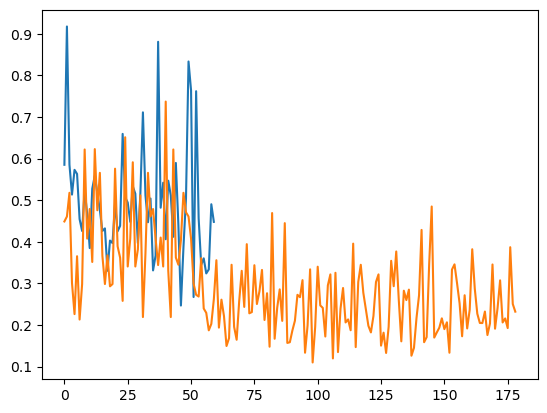

In [11]:
import matplotlib.pyplot as plt 
plt.plot(pos_sims)
plt.plot(neg_sims)

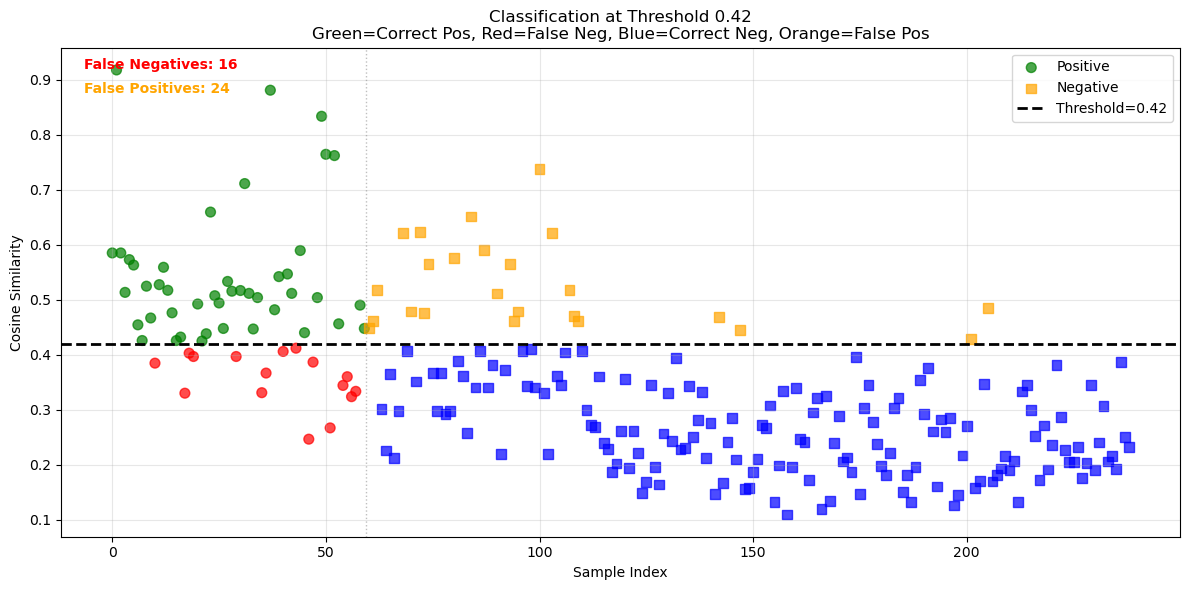

In [12]:
import matplotlib.pyplot as plt
import numpy as np

threshold = 0.42

# Create combined plot
fig, ax = plt.subplots(figsize=(12, 6))

# Plot positive samples with color coding
pos_indices = range(len(pos_sims))
pos_colors = ['green' if sim >= threshold else 'red' for sim in pos_sims]
ax.scatter(pos_indices, pos_sims, color=pos_colors, 
           label='Positive', alpha=0.7, s=50, marker='o')

# Plot negative samples with color coding
neg_indices = range(len(pos_sims), len(pos_sims) + len(neg_sims))
neg_colors = ['blue' if sim < threshold else 'orange' for sim in neg_sims]
ax.scatter(neg_indices, neg_sims, color=neg_colors, 
           label='Negative', alpha=0.7, s=50, marker='s')

# Add threshold line
ax.axhline(y=threshold, color='black', linestyle='--', linewidth=2, label=f'Threshold={threshold}')

# Add vertical separator between positive and negative sets
ax.axvline(x=len(pos_sims)-0.5, color='gray', linestyle=':', linewidth=1, alpha=0.5)

# Add labels and legend
ax.set_xlabel('Sample Index')
ax.set_ylabel('Cosine Similarity')
ax.set_title(f'Classification at Threshold {threshold}\nGreen=Correct Pos, Red=False Neg, Blue=Correct Neg, Orange=False Pos')
ax.legend(loc='best')
ax.grid(True, alpha=0.3)

# Add annotations for misclassified counts
misclassified_pos = sum(1 for s in pos_sims if s < threshold)
misclassified_neg = sum(1 for s in neg_sims if s >= threshold)
ax.text(0.02, 0.98, f'False Negatives: {misclassified_pos}', transform=ax.transAxes, 
        verticalalignment='top', color='red', fontweight='bold')
ax.text(0.02, 0.93, f'False Positives: {misclassified_neg}', transform=ax.transAxes, 
        verticalalignment='top', color='orange', fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
# 77% correct 

### XGBoost 

In [19]:
def extract_features(S): #,embA,embB): 
    maxA = S.max(axis=1)
    maxB = S.max(axis=0)
    # Matching strength overall 
    features = [
        #maxA.mean(),
        #maxA.max(),
        #maxA.min(),
    
        #maxB.mean(),
        #maxB.max(),
        #maxB.min(),
    
        S.mean(),
        S.max(),
        S.std()
    ]
    # Coverage: how much of one course is covered by the other? 
    features.extend([
    (S > 0.5).mean(),
    #(maxB > 0.5).mean(),
    (S > 0.6).mean(),
    #(maxB > 0.6).mean(),
    (S > 0.7).mean(),
    #(maxA > 0.8).mean(),
    #(maxB > 0.7).mean(),
    #(maxB > 0.8).mean()
    ])

    # Average similarity in LOs 
    #avgA = embA.mean(axis=0)
    #avgB = embB.mean(axis=0)
   # course_similarity = cosine_similarity(
    #    [avgA],[avgB]
   # )[0,0]
    
    #features.append(course_similarity)
    return features 

#print(extract_features(sim_matrix,emb1,emb2))

In [20]:
pos_sims = [] 
features = [] 
for i, (course1, course2) in enumerate(positives):  #[0:23]:
    result = df_TUE.loc[df_TUE['course_code'] == course1, 'learning_outcomes'] 
    LOs1 = ast.literal_eval(result.iloc[0])
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, 'learning_outcomes'].iloc[0] == '[]': 
        result = df_TUE.loc[df_TUE['course_code'] == course2, 'learning_outcomes'] 
        LOs2 = ast.literal_eval(result.iloc[0])
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, 'learning_outcomes'] 
        LOs2 = ast.literal_eval(result.iloc[0])
    # compute similarity 
    emb1 = embed_objectives(model, LOs1)
    emb2 = embed_objectives(model, LOs2)

    if len(emb1) == 0 or len(emb2) == 0:
        print('no') 
        print('course1')
        print(LOs1)
        print('course2')
        print(LOs2)
        pos_sims.append([])
    else: 
        # Pairwise cosine similarity matrix
        sim_matrix = cosine_similarity(emb1, emb2)
        pos_sims.append(sim_matrix) 
        features.append(extract_features(sim_matrix)) #, emb1, emb2))

In [21]:
print(features[0])

[0.536763, 0.61869997, 0.05557139, 0.7222222222222222, 0.1111111111111111, 0.0]


In [44]:
from nltk.tokenize import PunktTokenizer
def split_sentences(text): 
    # Download the 'punkt' data if you haven't already
    # import nltk
    # nltk.download('punkt')
    
    #text = "Dr. Smith is here. She has a Ph.D. in Chemistry."
    tokenizer = PunktTokenizer()
    sentences = tokenizer.tokenize(text)
    
    return sentences
# Output: ['Dr. Smith is here.', 'She has a Ph.D. in Chemistry.']

def extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='topics'):
    result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
    LOs1 =result.iloc[0]
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, field].iloc[0] == '[]': 
        result = df_TUE.loc[df_TUE['course_code'] == course2, field] 
        if not result.empty: 
            LOs2 = result.iloc[0]
        else: 
            return np.zeros((2,2))
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, field] 
        if not result.empty: 
            LOs2 = result.iloc[0]
        else: 
            return np.zeros((2,2))

    # compute similarity 
    emb1 = embed_objectives(model, split_sentences(str(LOs1)))
    emb2 = embed_objectives(model, split_sentences(str(LOs2)))
    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)
    return sim_matrix

sim_desc = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='description')
print(np.shape(sim_desc))

(3, 5)


In [55]:
pos_sims = [] 
features = [] 
for i, (course1, course2) in enumerate(positives):  #[0:23]:
    # description 
    # topics (not for now) 
    # title 
    # prerequisites 
    # level
    sim_level = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='level')
    sim_title = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='title')
    sim_desc = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='description')
    sim_LOs = extract_sim_matrix_pos(df_TUE, df_OVL, course1, course2, field='learning_outcomes') 
    sim_pre= extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='prerequisites')
    feature = [np.mean(sim_level)] + [np.mean(sim_title)] + extract_features(sim_desc) + extract_features(sim_LOs) + [np.mean(sim_pre)]
    features.append(feature)

In [52]:
print(np.shape(sim_level))
print(np.shape(sim_title))
print(np.shape(sim_LOs))
print(np.shape(sim_desc))
print(np.shape(sim_pre))
print(len(feature))

(1, 1)
(1, 1)
(3, 6)
(3, 5)
(1, 1)
15


In [56]:
def extract_sim_matrix_pos(df_TUE, df_OVL, course1, course2, field='topics'):
    result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
    LOs1 = ast.literal_eval(result.iloc[0])
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, field].iloc[0] == '[]': 
        result = df_TUE.loc[df_TUE['course_code'] == course2, field] 
        LOs2 = ast.literal_eval(result.iloc[0])
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, field] 
        LOs2 = ast.literal_eval(result.iloc[0])
  #  print('LO1: ',LOs1)
  #  print('LO2: ',LOs2)
    # compute similarity 
    emb1 = embed_objectives(model, LOs1)
    emb2 = embed_objectives(model, LOs2)
    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)
    return sim_matrix
    #features.append(extract_features(sim_matrix, emb1, emb2))

In [57]:
def extract_sim_matrix_neg(df_TUE, df_OVL, course1, course2, field='topics'):
    result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
    LOs1 = ast.literal_eval(result.iloc[0])
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, field].empty: 
        result = df_TUE.loc[df_TUE['course_code'] == course2, field] 
         
        if not result.iloc[0] == '[]': 
            LOs2 = ast.literal_eval(result.iloc[0])
        else: 
            return np.zeros((2,2))
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, field] 
        
        if not result.iloc[0] == '[]': 
            LOs2 = ast.literal_eval(result.iloc[0])
        else: 
            return np.zeros((2,2))
    # compute similarity 
    emb1 = embed_objectives(model, LOs1)
    emb2 = embed_objectives(model, LOs2)
    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)
    return sim_matrix
    #features.append(extract_features(sim_matrix, emb1, emb2))

def extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='topics'):
    result = df_TUE.loc[df_TUE['course_code'] == course1, field] 
    LOs1 =result.iloc[0]
    #LO2 can be either from original or overlap courses 
    if df_OVL.loc[df_OVL['course_code'] == course2, field].empty:
        result = df_TUE.loc[df_TUE['course_code'] == course2, field] 
        if not result.empty: 
            LOs2 = result.iloc[0]
        else: 
            return np.zeros((2,2))
    else: 
        result = df_OVL.loc[df_OVL['course_code'] == course2, field] 
        if not result.empty: 
            LOs2 = result.iloc[0]
        else: 
            return np.zeros((2,2))
    # compute similarity 
    emb1 = embed_objectives(model, split_sentences(str(LOs1)))
    emb2 = embed_objectives(model,split_sentences(str(LOs2)))
    # Pairwise cosine similarity matrix
    sim_matrix = cosine_similarity(emb1, emb2)
    return sim_matrix
    #features.append(extract_features(sim_matrix, emb1, emb2))

In [59]:
# negatives 
neg_features = [] 
for i, (course1, course2) in enumerate(negatives):  #[0:23]:
    # description 
    # topics (not for now) 
    # title 
    # prerequisites 
    # level
    sim_level = extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='level')
    sim_title = extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='title')
    sim_desc = extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='description')
    sim_LOs = extract_sim_matrix_neg(df_TUE, df_OVL, course1, course2, field='learning_outcomes') 
    sim_pre= extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='prerequisites')
    feature = extract_features(sim_level) + extract_features(sim_title) + extract_features(sim_desc) + extract_features(sim_LOs) + extract_features(sim_pre) 
    feature = [np.mean(sim_level)] + [np.mean(sim_title)] + extract_features(sim_desc) + extract_features(sim_LOs) + [np.mean(sim_pre)]
    neg_features.append(feature)
   # break
#print(feature)
#print(len(feature))

In [81]:
# train on all data, final model 
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import joblib

# Use all data for cross-validation
X_all = np.vstack([features, neg_features])
y_all = np.hstack([np.ones(len(features)), 
                  np.zeros(len(neg_features))])

# Define and TRAIN the model on ALL data
clf = RandomForestClassifier(
    n_estimators=250,
    max_depth=3,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Train the model on all data
clf.fit(X_all, y_all)

# Save the trained model
joblib.dump(clf, '/mimer/NOBACKUP/groups/naiss2024-22-903/WASP_NLP/project/random_forest_model.pkl')
print("Model saved successfully!")

# To load the model later:
# loaded_model = joblib.load('random_forest_model.pkl')

Model saved successfully!


In [82]:
print(X_all.shape)

(240, 15)


In [67]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
import numpy as np
from xgboost import XGBClassifier


# Use all data for cross-validation
X_all = np.vstack([features, neg_features])
y_all = np.hstack([np.ones(len(features)), 
                  np.zeros(len(neg_features))])

# Define the model
clf = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    scale_pos_weight=len(neg_features)/len(features),
    random_state=42
)

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Various metrics via cross-validation
accuracy_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='roc_auc')
precision_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='precision')
recall_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='recall')

print("=== Cross-Validation Results (5-fold) ===")
print(f"Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std():.4f})")
print(f"Precision: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")
print(f"Recall: {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
print(f"F1-Score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print(f"ROC-AUC: {roc_auc_scores.mean():.4f} (+/- {roc_auc_scores.std():.4f})")

=== Cross-Validation Results (5-fold) ===
Accuracy: 0.8542 (+/- 0.0323)
Precision: 0.6801 (+/- 0.0584)
Recall: 0.8000 (+/- 0.1247)
F1-Score: 0.7295 (+/- 0.0703)
ROC-AUC: 0.9139 (+/- 0.0304)


In [62]:
# also try a logistic regression model. 
from sklearn.linear_model import LogisticRegression

clf = LogisticRegression(
    penalty='l2',
    C=0.5
)
# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Various metrics via cross-validation
accuracy_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='roc_auc')
precision_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='precision')
recall_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='recall')

print("=== Cross-Validation Results (5-fold) ===")
print(f"Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std():.4f})")
print(f"Precision: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")
print(f"Recall: {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
print(f"F1-Score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print(f"ROC-AUC: {roc_auc_scores.mean():.4f} (+/- {roc_auc_scores.std():.4f})")

=== Cross-Validation Results (5-fold) ===
Accuracy: 0.7833 (+/- 0.0339)
Precision: 0.7639 (+/- 0.2159)
Recall: 0.2833 (+/- 0.1130)
F1-Score: 0.3820 (+/- 0.1265)
ROC-AUC: 0.8829 (+/- 0.0424)


In [66]:
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# Use all data for cross-validation
X_all = np.vstack([features, neg_features])
y_all = np.hstack([np.ones(len(features)), 
                  np.zeros(len(neg_features))])

# Define the Random Forest model
# Key changes explained below
clf = RandomForestClassifier(
    n_estimators=250,           # Same as XGBoost's n_estimators
    max_depth=3,                # Same max_depth
    class_weight='balanced',    # This replaces scale_pos_weight for imbalance
    random_state=42,
    n_jobs=-1                   # Use all CPU cores for faster training
)

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Various metrics via cross-validation
accuracy_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='accuracy')
f1_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='f1')
roc_auc_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='roc_auc')
precision_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='precision')
recall_scores = cross_val_score(clf, X_all, y_all, cv=cv, scoring='recall')

print("=== Cross-Validation Results (5-fold) ===")
print(f"Accuracy: {accuracy_scores.mean():.4f} (+/- {accuracy_scores.std():.4f})")
print(f"Precision: {precision_scores.mean():.4f} (+/- {precision_scores.std():.4f})")
print(f"Recall: {recall_scores.mean():.4f} (+/- {recall_scores.std():.4f})")
print(f"F1-Score: {f1_scores.mean():.4f} (+/- {f1_scores.std():.4f})")
print(f"ROC-AUC: {roc_auc_scores.mean():.4f} (+/- {roc_auc_scores.std():.4f})")

=== Cross-Validation Results (5-fold) ===
Accuracy: 0.8417 (+/- 0.0339)
Precision: 0.6357 (+/- 0.0565)
Recall: 0.8833 (+/- 0.1000)
F1-Score: 0.7357 (+/- 0.0531)
ROC-AUC: 0.9157 (+/- 0.0402)


In [69]:
# thresholding: 
pos_sims = [] 
featuresth = [] 
for i, (course1, course2) in enumerate(positives):  #[0:23]:
    # description 
    # topics (not for now) 
    # title 
    # prerequisites 
    # level
    sim_level = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='level')
    sim_title = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='title')
    sim_desc = extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='description')
    sim_LOs = extract_sim_matrix_pos(df_TUE, df_OVL, course1, course2, field='learning_outcomes') 
    sim_pre= extract_sim_matrix_pos3(df_TUE, df_OVL, course1, course2, field='prerequisites')
    feature = [np.mean(sim_level)] + [np.mean(sim_title)] + [np.mean(sim_desc)]+ [np.mean(sim_LOs)]+[np.mean(sim_pre)]
    featuresth.append(feature)
# negatives 
neg_featuresth = [] 
for i, (course1, course2) in enumerate(negatives):  #[0:23]:
    # description 
    # topics (not for now) 
    # title 
    # prerequisites 
    # level
    sim_level = extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='level')
    sim_title = extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='title')
    sim_desc = extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='description')
    sim_LOs = extract_sim_matrix_neg(df_TUE, df_OVL, course1, course2, field='learning_outcomes') 
    sim_pre= extract_sim_matrix_neg2(df_TUE, df_OVL, course1, course2, field='prerequisites')
    feature = extract_features(sim_level) + extract_features(sim_title) + extract_features(sim_desc) + extract_features(sim_LOs) + extract_features(sim_pre) 
    feature = [np.mean(sim_level)] + [np.mean(sim_title)] + [np.mean(sim_desc)]+ [np.mean(sim_LOs)]+[np.mean(sim_pre)]
    neg_featuresth.append(feature)

In [70]:
X_all = np.vstack([featuresth, neg_featuresth])   # shape (n_samples, 5)
y_all = np.hstack([
    np.ones(len(featuresth)),
    np.zeros(len(neg_featuresth))
])

from sklearn.metrics import f1_score
import numpy as np

def find_best_threshold(scores, labels):
    """
    Returns threshold maximizing F1.
    """
    thresholds = np.unique(scores)

    best_thr = thresholds[0]
    best_f1 = -1

    for t in thresholds:
        preds = (scores >= t).astype(int)
        f1 = f1_score(labels, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = t

    return best_thr

from sklearn.model_selection import StratifiedKFold

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [79]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

feature_names = [
    "level",
    "title",
    "description",
    "LOs",
    "prerequisites"
]

from itertools import product
from sklearn.metrics import f1_score

def find_best_thresholds(X_train, y_train):
    # candidate thresholds for each feature
    candidates = [
        np.quantile(X_train[:, i], np.linspace(0.45, 0.95, 10))
        for i in range(X_train.shape[1])
    ]

    best_score = -1
    best_thresholds = None

    for thresholds in product(*candidates):

        preds = np.all(X_train >= thresholds, axis=1)

        score = f1_score(y_train, preds)

        if score > best_score:
            best_score = score
            best_thresholds = thresholds

    return np.array(best_thresholds)

for j, name in enumerate(feature_names):

    accs = []
    precs = []
    recs = []
    f1s = []
    aucs = []

    for train_idx, test_idx in cv.split(X_all, y_all):

        X_train = X_all[train_idx]
        X_test = X_all[test_idx]

        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        # learn threshold ONLY on training fold
        thr = find_best_thresholds(X_train, y_train)
        print('best thresholds: ',thr) 

        # classify test fold
        preds = np.all(X_test >= thr, axis=1) #.astype(int)

        accs.append(accuracy_score(y_test, preds))
        precs.append(precision_score(y_test, preds))
        recs.append(recall_score(y_test, preds))
        f1s.append(f1_score(y_test, preds))

        # use similarity scores for ROC-AUC
        aucs.append(roc_auc_score(y_test, X_test[:, j]))

    results[name] = {
        "Accuracy": (np.mean(accs), np.std(accs)),
        "Precision": (np.mean(precs), np.std(precs)),
        "Recall": (np.mean(recs), np.std(recs)),
        "F1": (np.mean(f1s), np.std(f1s)),
        "ROC-AUC": (np.mean(aucs), np.std(aucs)),
    }
for feat, metrics in results.items():

    print(f"\n===== {feat} =====")

    for metric, (mean, std) in metrics.items():
        print(f"{metric}: {mean:.4f} (+/- {std:.4f})")

best thresholds:  [0.45576102 0.24035358 0.26691288 0.17703332 0.22559156]
best thresholds:  [0.45576102 0.23839144 0.26768501 0.17971083 0.24350785]
best thresholds:  [0.45576102 0.25214745 0.33499516 0.1901115  0.24367712]
best thresholds:  [0.45576102 0.24170519 0.2657565  0.18199043 0.24376299]
best thresholds:  [0.45576102 0.24170271 0.26423152 0.18680488 0.24724827]
best thresholds:  [0.45576102 0.24035358 0.26691288 0.17703332 0.22559156]
best thresholds:  [0.45576102 0.23839144 0.26768501 0.17971083 0.24350785]
best thresholds:  [0.45576102 0.25214745 0.33499516 0.1901115  0.24367712]
best thresholds:  [0.45576102 0.24170519 0.2657565  0.18199043 0.24376299]
best thresholds:  [0.45576102 0.24170271 0.26423152 0.18680488 0.24724827]
best thresholds:  [0.45576102 0.24035358 0.26691288 0.17703332 0.22559156]
best thresholds:  [0.45576102 0.23839144 0.26768501 0.17971083 0.24350785]


KeyboardInterrupt: 

In [71]:
# train for individual data fields (forget about the rest) and tune the threshold for those. 
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
)

feature_names = [
    "level",
    "title",
    "description",
    "LOs",
    "prerequisites"
]

results = {}

for j, name in enumerate(feature_names):

    accs = []
    precs = []
    recs = []
    f1s = []
    aucs = []

    for train_idx, test_idx in cv.split(X_all, y_all):

        X_train = X_all[train_idx]
        X_test = X_all[test_idx]

        y_train = y_all[train_idx]
        y_test = y_all[test_idx]

        # learn threshold ONLY on training fold
        thr = find_best_threshold(X_train[:, j], y_train)

        # classify test fold
        preds = (X_test[:, j] >= thr).astype(int)

        accs.append(accuracy_score(y_test, preds))
        precs.append(precision_score(y_test, preds))
        recs.append(recall_score(y_test, preds))
        f1s.append(f1_score(y_test, preds))

        # use similarity scores for ROC-AUC
        aucs.append(roc_auc_score(y_test, X_test[:, j]))

    results[name] = {
        "Accuracy": (np.mean(accs), np.std(accs)),
        "Precision": (np.mean(precs), np.std(precs)),
        "Recall": (np.mean(recs), np.std(recs)),
        "F1": (np.mean(f1s), np.std(f1s)),
        "ROC-AUC": (np.mean(aucs), np.std(aucs)),
    }

In [78]:
results[name] = {
        "Accuracy": (np.mean(accs), np.std(accs)),
        "Precision": (np.mean(precs), np.std(precs)),
        "Recall": (np.mean(recs), np.std(recs)),
        "F1": (np.mean(f1s), np.std(f1s)),
        "ROC-AUC": (np.mean(aucs), np.std(aucs)),
    }

for feat, metrics in results.items():

    print(f"\n===== {feat} =====")

    for metric, (mean, std) in metrics.items():
        print(f"{metric}: {mean:.4f} (+/- {std:.4f})")


===== level =====
Accuracy: nan (+/- nan)
Precision: nan (+/- nan)
Recall: nan (+/- nan)
F1: nan (+/- nan)
ROC-AUC: nan (+/- nan)

===== title =====
Accuracy: 0.7250 (+/- 0.0156)
Precision: 0.4706 (+/- 0.0161)
Recall: 0.7500 (+/- 0.1179)
F1: 0.5740 (+/- 0.0307)
ROC-AUC: 0.7981 (+/- 0.0250)

===== description =====
Accuracy: 0.8375 (+/- 0.0595)
Precision: 0.6661 (+/- 0.1215)
Recall: 0.7333 (+/- 0.1333)
F1: 0.6930 (+/- 0.1127)
ROC-AUC: 0.8616 (+/- 0.0650)

===== LOs =====
Accuracy: 0.7583 (+/- 0.0909)
Precision: 0.5375 (+/- 0.1422)
Recall: 0.7167 (+/- 0.1000)
F1: 0.6068 (+/- 0.1149)
ROC-AUC: 0.8134 (+/- 0.0733)

===== prerequisites =====
Accuracy: 0.2708 (+/- 0.0186)
Precision: 0.2487 (+/- 0.0091)
Recall: 0.9500 (+/- 0.0667)
F1: 0.3941 (+/- 0.0167)
ROC-AUC: 0.5419 (+/- 0.0643)


/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/numpy/core/_methods.py:269: RuntimeWarning: Degrees of freedom <= 0 for slice
  ret = _var(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/numpy/core/_methods.py:226: RuntimeWarning: invalid value encountered in divide
  arrmean = um.true_divide(arrmean, div, out=arrmean,
/mimer/NOBACKUP/groups/naiss2024-22-903/anaconda3/envs/NLP/lib/python3.8/site-packages/numpy/core/_methods.py:261: RuntimeWarning: inval

In [72]:
for feat, metrics in results.items():

    print(f"\n===== {feat} =====")

    for metric, (mean, std) in metrics.items():
        print(f"{metric}: {mean:.4f} (+/- {std:.4f})")


===== level =====
Accuracy: 0.4625 (+/- 0.0333)
Precision: 0.2885 (+/- 0.0135)
Recall: 0.7833 (+/- 0.0667)
F1: 0.4212 (+/- 0.0211)
ROC-AUC: 0.5954 (+/- 0.0633)

===== title =====
Accuracy: 0.7250 (+/- 0.0156)
Precision: 0.4706 (+/- 0.0161)
Recall: 0.7500 (+/- 0.1179)
F1: 0.5740 (+/- 0.0307)
ROC-AUC: 0.7981 (+/- 0.0250)

===== description =====
Accuracy: 0.8375 (+/- 0.0595)
Precision: 0.6661 (+/- 0.1215)
Recall: 0.7333 (+/- 0.1333)
F1: 0.6930 (+/- 0.1127)
ROC-AUC: 0.8616 (+/- 0.0650)

===== LOs =====
Accuracy: 0.7583 (+/- 0.0909)
Precision: 0.5375 (+/- 0.1422)
Recall: 0.7167 (+/- 0.1000)
F1: 0.6068 (+/- 0.1149)
ROC-AUC: 0.8134 (+/- 0.0733)

===== prerequisites =====
Accuracy: 0.2708 (+/- 0.0186)
Precision: 0.2487 (+/- 0.0091)
Recall: 0.9500 (+/- 0.0667)
F1: 0.3941 (+/- 0.0167)
ROC-AUC: 0.5419 (+/- 0.0643)


In [73]:
# single global threshold: 
global_scores = X_all.mean(axis=1) 
accs = []
precs = []
recs = []
f1s = []
aucs = []

for train_idx, test_idx in cv.split(X_all, y_all):

    train_scores = global_scores[train_idx]
    test_scores = global_scores[test_idx]

    y_train = y_all[train_idx]
    y_test = y_all[test_idx]

    thr = find_best_threshold(train_scores, y_train)

    preds = (test_scores >= thr).astype(int)

    accs.append(accuracy_score(y_test, preds))
    precs.append(precision_score(y_test, preds))
    recs.append(recall_score(y_test, preds))
    f1s.append(f1_score(y_test, preds))
    aucs.append(roc_auc_score(y_test, test_scores))

print("\n===== Global threshold =====")
print(f"Accuracy: {np.mean(accs):.4f} (+/- {np.std(accs):.4f})")
print(f"Precision: {np.mean(precs):.4f} (+/- {np.std(precs):.4f})")
print(f"Recall: {np.mean(recs):.4f} (+/- {np.std(recs):.4f})")
print(f"F1: {np.mean(f1s):.4f} (+/- {np.std(f1s):.4f})")
print(f"ROC-AUC: {np.mean(aucs):.4f} (+/- {np.std(aucs):.4f})")


===== Global threshold =====
Accuracy: 0.7000 (+/- 0.0626)
Precision: 0.4553 (+/- 0.0646)
Recall: 0.7833 (+/- 0.1130)
F1: 0.5680 (+/- 0.0517)
ROC-AUC: 0.8310 (+/- 0.0548)


### Old code 

In [95]:
from rulefit import RuleFit
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import numpy as np

# Use all data for cross-validation
X_all = np.vstack([features, neg_features])
y_all = np.hstack([np.ones(len(features)), 
                  np.zeros(len(neg_features))])

# 5-fold cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Manual CV for RuleFit (with proper re-initialization)
auc_scores = []
accuracy_scores = []

for fold, (train_idx, val_idx) in enumerate(cv.split(X_all, y_all)):
    X_train, X_val = X_all[train_idx], X_all[val_idx]
    y_train, y_val = y_all[train_idx], y_all[val_idx]
    
    # CRITICAL FIX: Re-initialize the model inside the loop
    clf_rule = RuleFit(
        tree_size=4,
        sample_fract='balanced',
        max_rules=20,
        memory_par=0.01,
        rfmode='classification',
        lin_standardise=True,
        random_state=42 + fold,  # Different seed per fold
       # n_estimators=50,         # Number of trees (increase for better performance)
        tree_generator=None#,     # Use default GradientBoostingClassifier
      #  verbose=False
    )
    
    # Fit on training data
    # feature_names can be a list of strings
    feature_names = [f'feature_{i}' for i in range(X_train.shape[1])]
    clf_rule.fit(X_train, y_train, feature_names=feature_names)
    
    # Predict on validation (RuleFit returns probabilities for classification)
    y_pred_proba = clf_rule.predict(X_val)
    
    # Calculate metrics
    auc = roc_auc_score(y_val, y_pred_proba)
    auc_scores.append(auc)
    
    # For accuracy, we need to threshold at 0.5
    y_pred_class = (y_pred_proba > 0.5).astype(int)
    acc = (y_pred_class == y_val).mean()
    accuracy_scores.append(acc)
    
    print(f"Fold {fold+1} - AUC: {auc:.3f}, Accuracy: {acc:.3f}")

print(f"\nRuleFit - Average AUC: {np.mean(auc_scores):.3f} (+/- {np.std(auc_scores):.3f})")
print(f"RuleFit - Average Accuracy: {np.mean(accuracy_scores):.3f} (+/- {np.std(accuracy_scores):.3f})")


Fold 1 - AUC: 0.722, Accuracy: 0.792
Fold 2 - AUC: 0.694, Accuracy: 0.792
Fold 3 - AUC: 0.792, Accuracy: 0.854
Fold 4 - AUC: 0.847, Accuracy: 0.896
Fold 5 - AUC: 0.667, Accuracy: 0.750

RuleFit - Average AUC: 0.744 (+/- 0.066)
RuleFit - Average Accuracy: 0.817 (+/- 0.052)


In [96]:
# Get the rules and their coefficients (linear model)
rules = clf_rule.get_rules()
rules = rules[rules.coef != 0].sort_values('coef', ascending=False)

print("\n" + "="*80)
print("TOP RULES (Most Predictive):")
print("="*80)
print(rules[['rule', 'coef', 'support']].head(10).to_string())

# Interpret a single prediction
sample = X_all[0:1]  # First sample
prediction = clf_rule.predict(sample)[0]
print(f"\nPrediction for sample: {prediction:.3f}")
print("Rules that fired for this sample:")
for rule in clf_rule.get_rules().itertuples():
    if rule.coef != 0 and eval(rule.rule) if '&' in rule.rule else False:
        # This is simplified - in practice you'd use clf_rule.transform()
        pass


TOP RULES (Most Predictive):
                                                                                                                                        rule      coef   support
35                                                                                                                                feature_35  9.088511  1.000000
55                                     feature_31 <= 0.6164897084236145 & feature_10 <= 0.8730070292949677 & feature_34 > 0.4526461511850357  2.331467  0.041667
60                                   feature_15 <= 0.2405557706952095 & feature_35 <= 0.14103302359580994 & feature_36 > 0.10555555671453476  1.786623  0.093750
22                                                                                                                                feature_22  1.471961  1.000000
61  feature_45 > 0.23964590579271317 & feature_43 <= 0.40716099739074707 & feature_36 > 0.1180555559694767 & feature_16 > 0.9621428549289703  1.317153  0.208333
15  

NameError: name 'feature_35' is not defined

In [97]:
print(rules[['rule']].head(10).to_string())

                                                                                                                                        rule
35                                                                                                                                feature_35
55                                     feature_31 <= 0.6164897084236145 & feature_10 <= 0.8730070292949677 & feature_34 > 0.4526461511850357
60                                   feature_15 <= 0.2405557706952095 & feature_35 <= 0.14103302359580994 & feature_36 > 0.10555555671453476
22                                                                                                                                feature_22
61  feature_45 > 0.23964590579271317 & feature_43 <= 0.40716099739074707 & feature_36 > 0.1180555559694767 & feature_16 > 0.9621428549289703
15                                                                                                                                feature_15
66           